# 📈 Tahap 6: Evaluasi Model

Notebook ini mengevaluasi performa semua model yang sudah dilatih dan membandingkannya.

**Metrik evaluasi:**
- Accuracy
- Precision (weighted)
- Recall (weighted)
- F1-Score (weighted)
- Confusion Matrix (per model)
- Classification Report (per model)

**Prasyarat:** Notebook `03_modeling.ipynb` sudah dijalankan terlebih dahulu
(model & test data sudah tersimpan di `output/`).

**Input (dari `output/`):**
- `model_names.json`
- `*.pkl` (model-model)
- `label_encoder.pkl`
- `X_test.npz` & `y_test.npy`

**Output:** Confusion matrix per model → `output/<nama_model>_cm.png`

In [1]:
# ── Setup Path ──────────────────────────────────────────────────────────────
import os
import sys

def _find_root(start):
    """Cari root directory project (berisi folder 'src' dan 'data')."""
    d = start
    for _ in range(5):
        if os.path.isdir(os.path.join(d, 'src')) and os.path.isdir(os.path.join(d, 'data')):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            break
        d = parent
    return start

ROOT_DIR   = _find_root(os.path.abspath(os.getcwd()))
SRC_DIR    = os.path.join(ROOT_DIR, 'src')
OUTPUT_DIR = os.path.join(ROOT_DIR, 'output')

if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

print(f'ROOT_DIR   : {ROOT_DIR}')
print(f'OUTPUT_DIR : {OUTPUT_DIR}')

ROOT_DIR   : D:\Kuliah\Semester 6\Data Mining\Tubes\tugas-besar-datamining-kelompok3
OUTPUT_DIR : D:\Kuliah\Semester 6\Data Mining\Tubes\tugas-besar-datamining-kelompok3\output


In [2]:
# ── Import ──────────────────────────────────────────────────────────────────
import json
import pickle
import numpy as np
import scipy.sparse

from utils import evaluate_all_models

In [3]:
# ── Load Model Names ──────────────────────────────────────────────────────────
with open(os.path.join(OUTPUT_DIR, 'model_names.json'), 'r') as f:
    model_names = json.load(f)

print(f'Model yang ditemukan: {model_names}')

Model yang ditemukan: ['LR (Sebelum SMOTE)', 'SVM (Sebelum SMOTE)', 'NB (Sebelum SMOTE)', 'LR (Sesudah SMOTE)', 'SVM (Sesudah SMOTE)', 'NB (Sesudah SMOTE)']


In [4]:
# ── Load Semua Model ──────────────────────────────────────────────────────────
models = {}
for nama in model_names:
    nama_file = nama.replace(' ', '_').replace('(', '').replace(')', '') + '.pkl'
    path = os.path.join(OUTPUT_DIR, nama_file)
    with open(path, 'rb') as f:
        models[nama] = pickle.load(f)
    print(f'  Loaded: {nama_file}')

print(f'\nTotal model dimuat: {len(models)}')

  Loaded: LR_Sebelum_SMOTE.pkl
  Loaded: SVM_Sebelum_SMOTE.pkl
  Loaded: NB_Sebelum_SMOTE.pkl
  Loaded: LR_Sesudah_SMOTE.pkl
  Loaded: SVM_Sesudah_SMOTE.pkl
  Loaded: NB_Sesudah_SMOTE.pkl

Total model dimuat: 6


In [5]:
# ── Load Label Encoder & Test Data ───────────────────────────────────────────
with open(os.path.join(OUTPUT_DIR, 'label_encoder.pkl'), 'rb') as f:
    label_encoder = pickle.load(f)

# Load X_test (sparse matrix) & y_test (array)
X_test = scipy.sparse.load_npz(os.path.join(OUTPUT_DIR, 'X_test.npz'))
y_test = np.load(os.path.join(OUTPUT_DIR, 'y_test.npy'))

print(f'Kelas label  : {label_encoder.classes_}')
print(f'X_test shape : {X_test.shape}')
print(f'y_test shape : {y_test.shape}')

Kelas label  : ['Negatif' 'Netral' 'Positif']
X_test shape : (2058, 10000)
y_test shape : (2058,)



  RINGKASAN EVALUASI SEMUA MODEL

── LR (Sebelum SMOTE) ──
  Accuracy  : 0.6603  (66.03%)
  Precision : 0.7511
  Recall    : 0.6603
  F1-Score  : 0.6953

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.87      0.72      0.79      1669
      Netral       0.26      0.43      0.32       297
     Positif       0.18      0.35      0.23        92

    accuracy                           0.66      2058
   macro avg       0.43      0.50      0.45      2058
weighted avg       0.75      0.66      0.70      2058



[utils] Confusion matrix disimpan: D:\Kuliah\Semester 6\Data Mining\Tubes\tugas-besar-datamining-kelompok3\output\LR_Sebelum_SMOTE_cm.png


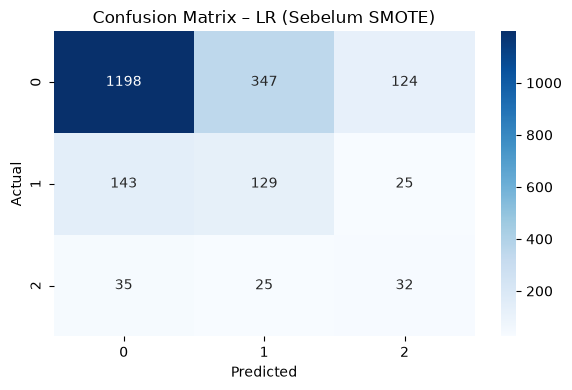


── SVM (Sebelum SMOTE) ──
  Accuracy  : 0.6555  (65.55%)
  Precision : 0.7461
  Recall    : 0.6555
  F1-Score  : 0.6894

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.87      0.71      0.78      1669
      Netral       0.25      0.47      0.33       297
     Positif       0.17      0.24      0.20        92

    accuracy                           0.66      2058
   macro avg       0.43      0.47      0.44      2058
weighted avg       0.75      0.66      0.69      2058



[utils] Confusion matrix disimpan: D:\Kuliah\Semester 6\Data Mining\Tubes\tugas-besar-datamining-kelompok3\output\SVM_Sebelum_SMOTE_cm.png


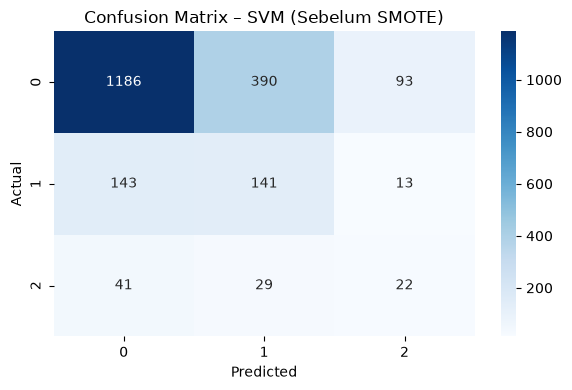


── NB (Sebelum SMOTE) ──
  Accuracy  : 0.8105  (81.05%)
  Precision : 0.6576
  Recall    : 0.8105
  F1-Score  : 0.7261

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.81      1.00      0.90      1669
      Netral       0.00      0.00      0.00       297
     Positif       0.00      0.00      0.00        92

    accuracy                           0.81      2058
   macro avg       0.27      0.33      0.30      2058
weighted avg       0.66      0.81      0.73      2058



C:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

[utils] Confusion matrix disimpan: D:\Kuliah\Semester 6\Data Mining\Tubes\tugas-besar-datamining-kelompok3\output\NB_Sebelum_SMOTE_cm.png


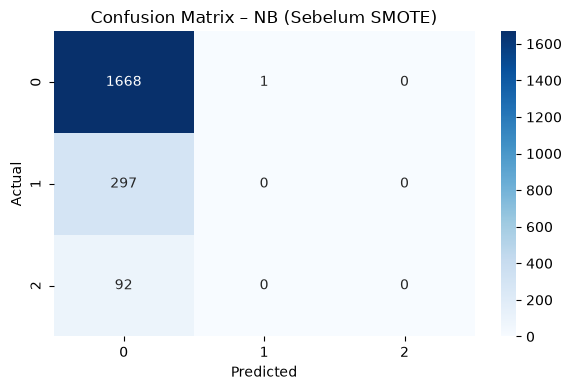


── LR (Sesudah SMOTE) ──
  Accuracy  : 0.6851  (68.51%)
  Precision : 0.7578
  Recall    : 0.6851
  F1-Score  : 0.7137

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.87      0.75      0.80      1669
      Netral       0.29      0.46      0.36       297
     Positif       0.18      0.30      0.22        92

    accuracy                           0.69      2058
   macro avg       0.45      0.50      0.46      2058
weighted avg       0.76      0.69      0.71      2058



[utils] Confusion matrix disimpan: D:\Kuliah\Semester 6\Data Mining\Tubes\tugas-besar-datamining-kelompok3\output\LR_Sesudah_SMOTE_cm.png


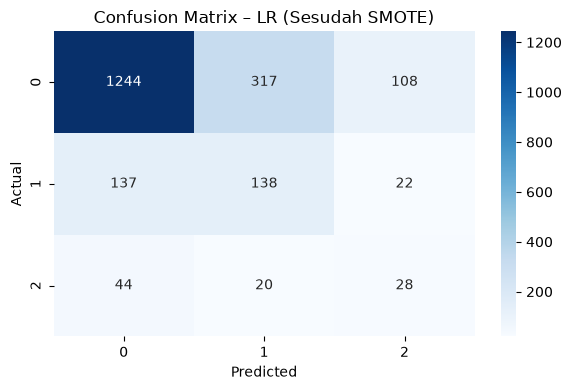


── SVM (Sesudah SMOTE) ──
  Accuracy  : 0.7094  (70.94%)
  Precision : 0.7566
  Recall    : 0.7094
  F1-Score  : 0.7287

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.87      0.78      0.82      1669
      Netral       0.31      0.47      0.37       297
     Positif       0.19      0.22      0.20        92

    accuracy                           0.71      2058
   macro avg       0.45      0.49      0.46      2058
weighted avg       0.76      0.71      0.73      2058



[utils] Confusion matrix disimpan: D:\Kuliah\Semester 6\Data Mining\Tubes\tugas-besar-datamining-kelompok3\output\SVM_Sesudah_SMOTE_cm.png


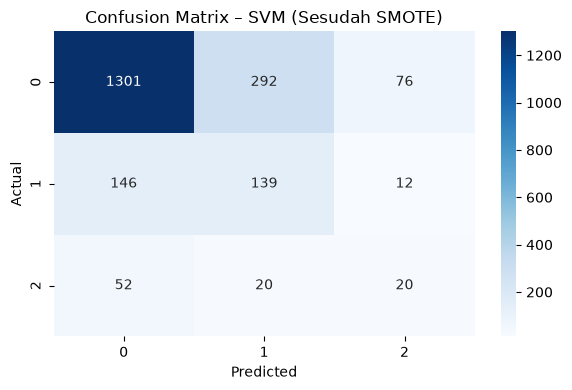


── NB (Sesudah SMOTE) ──
  Accuracy  : 0.6312  (63.12%)
  Precision : 0.7490
  Recall    : 0.6312
  F1-Score  : 0.6761

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.87      0.69      0.77      1669
      Netral       0.24      0.39      0.30       297
     Positif       0.13      0.37      0.19        92

    accuracy                           0.63      2058
   macro avg       0.42      0.48      0.42      2058
weighted avg       0.75      0.63      0.68      2058



[utils] Confusion matrix disimpan: D:\Kuliah\Semester 6\Data Mining\Tubes\tugas-besar-datamining-kelompok3\output\NB_Sesudah_SMOTE_cm.png


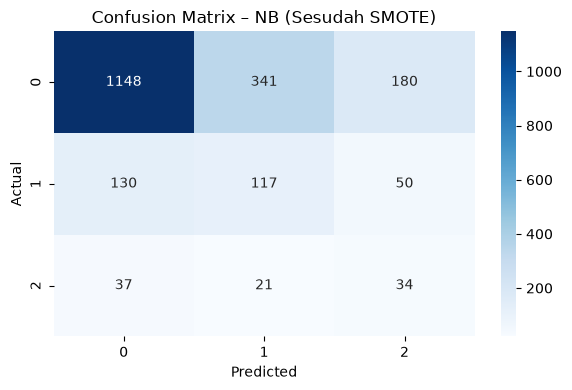


  TABEL PERBANDINGAN MODEL
                    Accuracy Precision  Recall F1-Score
Model                                                  
LR (Sebelum SMOTE)    0.6603    0.7511  0.6603   0.6953
SVM (Sebelum SMOTE)   0.6555    0.7461  0.6555   0.6894
NB (Sebelum SMOTE)    0.8105    0.6576  0.8105   0.7261
LR (Sesudah SMOTE)    0.6851    0.7578  0.6851   0.7137
SVM (Sesudah SMOTE)   0.7094    0.7566  0.7094   0.7287
NB (Sesudah SMOTE)    0.6312    0.7490  0.6312   0.6761


In [6]:
# ── Evaluasi Semua Model ──────────────────────────────────────────────────────
df_hasil = evaluate_all_models(
    models,
    X_test,
    y_test,
    label_encoder,
    save_dir=OUTPUT_DIR
)

In [7]:
# ── Tampilkan Tabel Perbandingan Model ────────────────────────────────────────
print('\n=== TABEL PERBANDINGAN MODEL ===')
df_hasil


=== TABEL PERBANDINGAN MODEL ===


,Accuracy,Precision,Recall,F1-Score
Model,,,,
LR (Sebelum SMOTE),0.6603,0.7511,0.6603,0.6953
SVM (Sebelum SMOTE),0.6555,0.7461,0.6555,0.6894
NB (Sebelum SMOTE),0.8105,0.6576,0.8105,0.7261
LR (Sesudah SMOTE),0.6851,0.7578,0.6851,0.7137
SVM (Sesudah SMOTE),0.7094,0.7566,0.7094,0.7287
NB (Sesudah SMOTE),0.6312,0.7490,0.6312,0.6761
